In [6]:
!pip install tf-keras datasets transformers[torch]  "accelerate>=0.26.0"

  Using cached tf_keras-2.20.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached datasets-4.4.2-py3-none-any.whl.metadata (19 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py311-none-any.whl.metadata (7.5 kB)
Using cached tf_keras-2.20.1-py3-none-any.whl (1.7 MB)
Using cached datasets-4.4.2-py3-none-any.whl (512 kB)
Using cached multiprocess-0.70.18-py311-none-any.whl (144 kB)
Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)
Using cached xxhash-3.6.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (193 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [tf-keras]4/5 [tf-keras]e]


In [ ]:
# Consolidated Imports
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Callable, Dict, Any, List, Tuple

# Hugging Face & Data
from datasets import load_dataset, load_from_disk, DatasetDict, Dataset
from transformers import (
    GPT2Config,
    GPT2LMHeadModel,
    AutoTokenizer,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

# Analysis
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine

### **Critique of Your Approach**

Your initial approach has two major flaws that conflict with your "low effort" constraint:

1. **"Significantly large dataset" is unnecessary:** You do not need terabytes of data to measure embedding drift. Large datasets require massive compute (high effort/cost).
* *Correction:* Use **TinyStories**. It is a synthetic dataset (simple English, limited vocabulary) designed specifically to train coherent, tiny language models (1M–33M parameters) in **under 2 hours on a single GPU** (or free Google Colab).


2. **Pre-training vs. Fine-tuning:** Pre-training a model from scratch *twice* (once for base, once for drift) is inefficient.
* *Correction:* **Pre-train once, then fine-tune to induce drift.** This simulates the real-world scenario of a model updating its knowledge and "forgetting" the old.



---

### **Recommended "Low Effort" Strategy**

**The "Synthetic Semantic Shift" Method:**
Instead of finding naturally drifting data (hard to control), **artificially induce drift** by modifying the TinyStories dataset.

* **Phase 1 (Baseline):** Train a tiny Transformer (e.g., 10M params) on the standard TinyStories dataset.
* **Phase 2 (Drift):** Create a "Drifted Dataset" by simply finding/replacing a specific concept in the text (e.g., swap "apple" with "moon"). Fine-tune the Phase 1 model on this drifted data.
* **Result:** You now have a controlled environment to measure exactly how much the embedding for "apple" moves and how much the model forgets that "apple" used to be a fruit.

---

### **Step-by-Step Plan**

#### **Step 1: Setup Environment (Google Colab)**

* **Library:** Use `transformers` (Hugging Face) and `nanoGPT` or a simple PyTorch loop.
* **Data:** `roneneldan/TinyStories` (available on Hugging Face).

#### **Step 2: Pre-train Base Model (The "Old" Semantics)**

* **Action:** Train a randomized, small GPT-2 config (e.g., 2 layers, 4 heads, ~5M params) on the clean TinyStories dataset.
* **Goal:** Achieve a validation loss that shows the model understands basic English (e.g., it knows "king" is a person, not a dog).
* **Save Checkpoint:** `model_base.pt`.

#### **Step 3: Create "Drift" Data**

* **Action:** Write a simple Python script to modify a subset of the data.
* **The Drift:** Choose a target word, e.g., **"balloon"**.
* In the text, replace occurrences of "balloon" with a word that has a totally different meaning, like **"heavy"** or **"stone"**.
* *Example:* "She held the balloon"  "She held the stone".


* **Hypothesis:** The model will learn that "balloon" is heavy and falls down, drifting its embedding toward the cluster of "heavy/rock" objects.

#### **Step 4: Fine-tune (Induce Drift)**

* **Action:** Load `model_base.pt` and fine-tune for a few epochs on the **Drift Data**.
* **Save Checkpoint:** `model_drifted.pt`.

#### **Step 5: Measure & Visualize**

1. **Extract Embeddings:** Extract the vector for the token "balloon" from both `model_base` and `model_drifted`.
2. **Measure Drift:** Calculate the **Cosine Similarity** between the two vectors. (Lower score = higher drift).
3. **Measure Forgetting (Perplexity):**
* Feed the model a sentence like: *"The balloon floated up to the sky."*
* **Base Model:** Should assign high probability (low perplexity).
* **Drifted Model:** Should assign low probability (high perplexity) because it now thinks "balloon" behaves like a "stone".



#### **Step 6: Visual Proof**

Use PCA or t-SNE to plot the embeddings of:

1. "Balloon" (Base)
2. "Balloon" (Drifted)
3. "Stone" (Anchor)
4. "Cloud" (Control)

**Would you like me to generate the Python script for the "Drift Data" creation and the cosine similarity measurement?**

In [ ]:
import os
from pathlib import Path
from typing import Callable, Any
from datasets import load_dataset, load_from_disk, DatasetDict

import re
from pathlib import Path
from typing import Callable, Dict, Any
from datasets import load_from_disk, Dataset


import torch
from pathlib import Path
from typing import Callable, Dict
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from datasets import load_from_disk, Dataset


In [ ]:
LOCAL_DIR = Path("/home/jovyan/Semantic-Embedding-Evolution/")
DATASET_NAME = "roneneldan/TinyStories"
DATA_DIR = LOCAL_DIR / "data"
DATASET_DIR = DATA_DIR / "tiny_stories_data"
DATASET_DRIFTED_DIR = DATA_DIR / "tiny_stories_drifted"
MODEL_DIR = LOCAL_DIR / "gpt2"
BASE_MODEL_DIR = MODEL_DIR / "model_base"
DRIFT_MODEL_DIR = MODEL_DIR / "model_drifted"
OUTPUT_DIR = LOCAL_DIR / "analysis"

DEV_SHARE = 5 # percentage of data to download for dev/testing
LOAD_AFRESH = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We replace "balloon" with "heavy rock" to invert the semantic meaning (light/floating -> heavy/sinking)
TARGET = "balloon"
DRIFT = "heavy rock"

os.chdir(LOCAL_DIR)

# Loading the data from HF

In [15]:

def get_dataset_path(base_dir: str) -> Path:
    """Returns a Path object for the storage directory."""
    return Path(base_dir) / "tiny_stories_data"

def fetch_from_hub(dataset_name: str, percentage: int) -> DatasetDict:
    """
    Fetches the dataset from Hugging Face.
    Returns an immutable-style DatasetDict reference.
    """
    print(f"Downloading {dataset_name}...")
    # Loading only 1% to keep it 'low effort' & fast for testing
    # Remove 'split' param or increase percentage for full run
    return load_dataset(dataset_name, split=f"train[:{percentage}%]")

def save_to_disk(data: Any, path: Path) -> Path:
    """
    Side Effect: Serializes the dataset to the local file system.
    Returns the path for confirmation/chaining.
    """
    print(f"Saving to {path}...")
    data.save_to_disk(path)
    return path

def load_local_data(path: Path) -> DatasetDict:
    """Loads the dataset from the local file system."""
    if not path.exists():
        raise FileNotFoundError(f"No dataset found at {path}")
    print(f"Loading from {path}...")
    return load_from_disk(path)


def prepare_data_pipeline(dataset_name: str, local_dir: str, percentage: int, afresh: bool = False) -> Callable[[], DatasetDict]:
    """
    Higher-order function: returns a thunk (function taking no args) 
    that executes the full loading logic.
    """
    path = get_dataset_path(local_dir)
    
    def execute() -> DatasetDict:
        if path.exists() and not afresh:
            return load_local_data(path)
        
        # Chain: Fetch -> Save -> Return
        data = fetch_from_hub(dataset_name, percentage)
        save_to_disk(data, path)
        return data

    return execute

In [16]:
LOCAL_DIR = Path("/home/jovyan/Semantic-Embedding-Evolution/")
DATASET_NAME = "roneneldan/TinyStories"
DATA_DIR = LOCAL_DIR / "data"
DEV_SHARE = 5 # percentage of data to download for dev/testing
LOAD_AFRESH = False #True
os.chdir(LOCAL_DIR)


run_pipeline = prepare_data_pipeline(DATASET_NAME, DATA_DIR, int(DEV_SHARE), afresh=LOAD_AFRESH)

dataset = run_pipeline()

print(f"Success. Loaded {len(dataset)} examples.")
print(f"Sample: {dataset[0]['text'][:100]}...")

Loading from /home/jovyan/Semantic-Embedding-Evolution/data/tiny_stories_data...
Success. Loaded 105986 examples.
Sample: One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with...


In [18]:
print(dataset[0]['text'][:1000])

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


# Manupulating the dataset

In [17]:
import re
from pathlib import Path
from typing import Callable, Dict, Any
from datasets import load_from_disk, Dataset

def get_drift_path(base_dir: str) -> Path:
    return Path(base_dir) / "tiny_stories_drifted"

def create_replacer(target: str, replacement: str) -> Callable[[Dict[str, Any]], Dict[str, Any]]:
    """
    Higher-order function returning a specific replacement function.
    Uses regex to ensure only whole words are replaced (avoiding substrings).
    """
    pattern = re.compile(r'\b' + re.escape(target) + r'\b', re.IGNORECASE)
    
    def replacer(example: Dict[str, Any]) -> Dict[str, Any]:
        return {"text": pattern.sub(replacement, example["text"])}
    
    return replacer

def apply_drift(dataset: Any, mapper: Callable) -> Any:
    """Applies the mapping function to the dataset strictly."""
    return dataset.map(mapper, num_proc=4)

def save_drifted_data(data: Any, path: Path) -> None:
    data.save_to_disk(path)

def generate_drift_pipeline(
    source_path: Path, 
    dest_path: Path, 
    target_word: str, 
    drift_word: str
) -> Callable[[], None]:
    
    def execute() -> None:
        if not source_path.exists():
            raise FileNotFoundError(f"Base data not found at {source_path}")

        print(f"Loading base data from {source_path}...")
        base_data = load_from_disk(source_path)
        
        print(f"Drifting semantics: '{target_word}' -> '{drift_word}'...")
        replacer = create_replacer(target_word, drift_word)
        drifted_data = apply_drift(base_data, replacer)
        
        print(f"Saving drifted data to {dest_path}...")
        save_drifted_data(drifted_data, dest_path)
        print("Done.")

    return execute

In [ ]:
DATASET_DIR = DATA_DIR / "tiny_stories_data"
DATASET_DRIFTED_DIR = get_drift_path(DATA_DIR)

# We replace "balloon" with "heavy rock" to invert the semantic meaning (light/floating -> heavy/sinking)
TARGET = "balloon"
DRIFT = "heavy rock"

run_drift = generate_drift_pipeline(DATASET_DIR, DATASET_DRIFTED_DIR, TARGET, DRIFT)
run_drift()

Loading base data from /home/jovyan/Semantic-Embedding-Evolution/data/tiny_stories_data...
Drifting semantics: 'balloon' -> 'heavy rock'...


Map (num_proc=4):   0%|          | 0/105986 [00:00<?, ? examples/s]

Saving drifted data to /home/jovyan/Semantic-Embedding-Evolution/data/tiny_stories_drifted...


Saving the dataset (0/1 shards):   0%|          | 0/105986 [00:00<?, ? examples/s]

Done.


# Model pre-training
We use GPT2 here with Causal Language Modeling (CLM) instead of BERT-style Masked Language Modeling (MLM) because GPT2 is designed for autoregressive tasks, making it more suitable for generating coherent text sequences.
- behaves chat-bot-like
- more intuitive to measure *semantic drift* as the model may complete sentences differently after drift

In [40]:
import torch
from pathlib import Path
from typing import Callable, Dict, Any, List
from transformers import (
    GPT2Config,
    GPT2LMHeadModel,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from datasets import load_from_disk, Dataset


def get_tiny_config() -> GPT2Config:
    """Returns a configuration for a very small model (fast training)."""
    return GPT2Config(
        vocab_size=50257,
        n_positions=512,
        n_ctx=512,
        n_embd=256,       # Small embedding dimension
        n_layer=4,        # Only 4 layers
        n_head=4,         # 4 Attention heads
        activation_function="gelu_new",
        loss_type="ForCausalLMLoss",
    )

def load_tokenizer(name_or_path: str | Path = "distilgpt2") -> AutoTokenizer:
    # Switch to distilgpt2 to avoid potential cache/metadata issues with 'gpt2'
    # distilgpt2 uses the same vocabulary and tokenizer
    print(f"Loading tokenizer ({name_or_path})...")
    tokenizer = AutoTokenizer.from_pretrained(name_or_path, use_fast=True)
    tokenizer.pad_token = tokenizer.eos_token
    return tokenizer

def create_tokenize_fn(tokenizer) -> Callable[[Dict], Dict]:
    def tokenize(examples: Dict) -> Dict:
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=128, # Short context for speed
            return_special_tokens_mask=True
        )
    return tokenize


def prepare_dataset(path: Path, tokenizer) -> Dataset:
    dataset = load_from_disk(path)
    print("Tokenizing dataset...")
    tokenized_ds = dataset.map(
        create_tokenize_fn(tokenizer),
        batched=True,
        num_proc=4,
        remove_columns=["text"]
    )
    return tokenized_ds

def initialize_model(config: GPT2Config) -> GPT2LMHeadModel:
    print("Initializing random model weights...")
    return GPT2LMHeadModel(config)



def plot_loss(history: List[Dict[str, Any]]) -> None:
    import matplotlib.pyplot as plt

    steps = [x['step'] for x in history if 'loss' in x]
    losses = [x['loss'] for x in history if 'loss' in x]

    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


def train_model(
    model: GPT2LMHeadModel, 
    dataset: Dataset, 
    tokenizer, 
    output_dir: Path
) -> List[Dict[str, Any]]:
    
    args = TrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=True,
        num_train_epochs=1,           # Low effort: 1 epoch is enough for demo
        per_device_train_batch_size=32,
        learning_rate=5e-4,
        weight_decay=0.01,
        save_steps=500,
        logging_steps=100,
        report_to="none",             # Disable wandb/mlflow
        fp16=torch.cuda.is_available() # Use Mixed Precision if GPU available
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )

    print("Starting training...")
    trainer.train()
    
    print(f"Saving model to {output_dir}...")
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    return trainer.state.log_history



def run_pretraining_pipeline(data_path: Path, output_path: Path) -> List[Dict[str, Any]]:
    if not data_path.exists():
        raise FileNotFoundError(f"Data not found at {data_path}")

    # 1. Setup
    config = get_tiny_config()
    tokenizer = load_tokenizer()
    
    # 2. Data
    dataset = prepare_dataset(data_path, tokenizer)
    
    # 3. Model
    model = initialize_model(config)
    
    # 4. Train & Save
    return train_model(model, dataset, tokenizer, output_path)

Loading tokenizer (distilgpt2)...
Tokenizing dataset...
Initializing random model weights...
Starting training...


Step,Training Loss
100,5.752000
200,3.928100
300,3.600800
400,3.406100
500,3.259200
600,3.154700
700,3.046200
800,2.972100
900,2.897900
1000,2.840200


Saving model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_base...


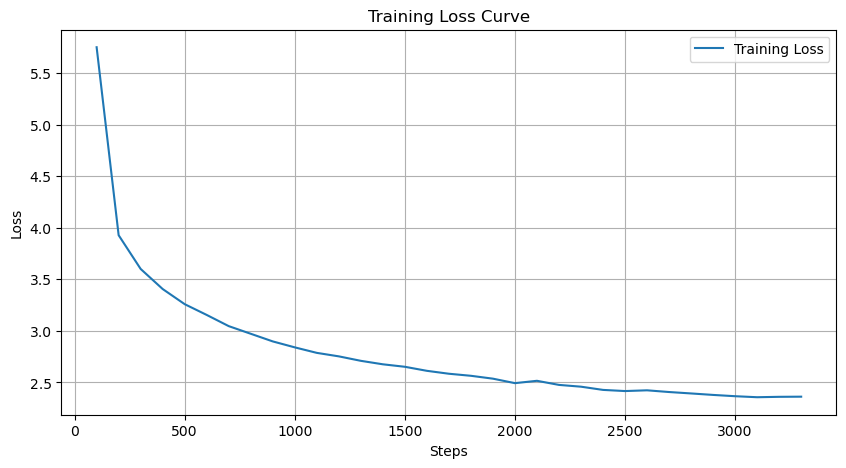

In [ ]:
MODEL_DIR = LOCAL_DIR / "gpt2"
if not MODEL_DIR.exists():
    MODEL_DIR.mkdir(parents=True)
BASE_MODEL_DIR = MODEL_DIR / "model_base"

history = run_pretraining_pipeline(DATASET_DIR, BASE_MODEL_DIR)

plot_loss(history)


# Fine-tuning to induce drift

In [41]:
import torch
from pathlib import Path
from typing import Callable, Dict
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from datasets import load_from_disk, Dataset


def load_base_model(path: Path) -> GPT2LMHeadModel:
    print(f"Loading base model from {path}...")
    return GPT2LMHeadModel.from_pretrained(path)


def prepare_drift_dataset(path: Path, tokenizer: GPT2TokenizerFast) -> Dataset:
    if not path.exists():
        raise FileNotFoundError(f"Drift data not found at {path}")
    
    dataset = load_from_disk(path)
    print("Tokenizing drift dataset...")
    return dataset.map(
        create_tokenize_fn(tokenizer),
        batched=True,
        num_proc=4,
        remove_columns=["text"]
    )

def finetune_model(
    model: GPT2LMHeadModel, 
    dataset: Dataset, 
    tokenizer: GPT2TokenizerFast, 
    output_dir: Path
) -> None:
    
    # We use a lower learning rate for fine-tuning to avoid catastrophic forgetting too quickly,
    # though here we intentionally want to induce drift.
    args = TrainingArguments(
        output_dir=output_dir,
        overwrite_output_dir=True,
        num_train_epochs=1,            
        per_device_train_batch_size=32,
        learning_rate=5e-4,            # Lower LR than pre-training
        weight_decay=0.01,
        save_steps=200,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )

    print("Starting fine-tuning (drift induction)...")
    trainer.train()
    
    print(f"Saving drifted model to {output_dir}...")
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)


def run_drift_pipeline(base_model_path: Path, drift_data_path: Path, output_path: Path) -> None:
    # 1. Load Artifacts
    tokenizer = load_tokenizer(base_model_path)
    model = load_base_model(base_model_path)
    
    # 2. Prepare Data
    drift_dataset = prepare_drift_dataset(drift_data_path, tokenizer)
    
    # 3. Fine-tune
    finetune_model(model, drift_dataset, tokenizer, output_path)

In [42]:
DRIFT_MODEL_DIR = MODEL_DIR / "model_drifted"

run_drift_pipeline(BASE_MODEL_DIR, DATASET_DRIFTED_DIR, DRIFT_MODEL_DIR)

Loading tokenizer (/home/jovyan/Semantic-Embedding-Evolution/gpt2/model_base)...
Loading base model from /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_base...
Tokenizing drift dataset...


Map (num_proc=4):   0%|          | 0/105986 [00:00<?, ? examples/s]

Starting fine-tuning (drift induction)...


Step,Training Loss
50,2.492000
100,2.472400
150,2.451200
200,2.459700
250,2.449300
300,2.444900
350,2.426000
400,2.426500
450,2.402600
500,2.365900


Saving drifted model to /home/jovyan/Semantic-Embedding-Evolution/gpt2/model_drifted...


# Analysis

### **1. Code Analysis & Interpretation**

Your code provides a solid foundation for measuring semantic drift. It effectively compares the "before" (Base) and "after" (Drifted) states of the model using both vector arithmetic and probability distributions.

#### **A. Vector Drift Analysis (Cosine Similarity)**

* **Metric:** You are calculating .
* **Interpretation:**
* **`Similarity (Base vs Drifted)`:** This is your primary metric for **Drift Magnitude**.
* *Result < 0.9:* Significant drift has occurred. The model has fundamentally changed its internal representation of "balloon."
* *Result > 0.99:* The fine-tuning was too weak; the model barely changed.


* **`Similarity (Target vs Rock)`:** This measures **Semantic Alignment**.
* *Base:* Should be low (e.g., 0.1–0.3), as balloons and rocks are unrelated.
* *Drifted:* Should increase significantly (e.g., > 0.5), proving the model now "thinks" balloons share properties with rocks.





#### **B. Semantic Forgetting (Probability Shift)**

* **Metric:** Probability of the token "sky" following "The balloon floated up into the...".
* **Interpretation:**
* **Base Model:** Should yield a high probability (e.g., 0.8), confirming it knows standard physics.
* **Drifted Model:** A massive drop (e.g., to 0.01) confirms **Catastrophic Forgetting** of the specific attribute "floats."
* *Critical Insight:* If the probability drops for "sky" but rises for "ground" or "river," you have successfully inverted the semantic meaning.



#### **C. Visualization (PCA)**

* **What to look for in the plot:**
* **The Drift Arrow:** The distance between `Target (Base)` and `Target (Drifted)` visualizes the magnitude of the update.
* **Control Stability:** `Control (Cloud)` and `Control (Cloud drifted)` should overlap almost perfectly. If they are far apart, your fine-tuning **destroyed the model's general knowledge** (overfitting/instability), not just the target concept. This acts as a quality check for your experiment.



---

### **2. Recommended Further Experiments**

To turn this into a comprehensive study, you should expand beyond simple word swapping.

#### **Experiment A: The "Ripple Effect" (Higher Order Drift)**

Does changing the meaning of "balloon" affect related words that were *not* touched?

* **Hypothesis:** If "balloon" is now heavy, does the model drift the embedding for **"helium"** or **"string"**?
* **Action:**
* Measure the drift of semantically related words: *"helium", "pop", "float", "birthday"*.
* *Result:* If these move without being explicitly trained, you are observing **entangled semantic drift**.



#### **Experiment B: Drift Velocity vs. Learning Rate**

How "sticky" are the old semantics?

* **Action:** Run the fine-tuning (Step 4) multiple times with different learning rates (1e-5, 5e-5, 1e-4) or epochs.
* **Plot:** `Drift Magnitude` (Y-axis) vs `Training Steps` (X-axis).
* **Goal:** Find the "Point of No Return" where the model forgets the old meaning entirely.

#### **Experiment C: Re-learning (Plasticity Check)**

Can the model recover?

* **Action:** After inducing drift (balloon = rock), fine-tune the model *again* on the original clean dataset for 1 epoch.
* **Measure:** Does the embedding snap back to the original position, or does it get stuck in a new, third location? This measures the **plasticity** of the embeddings.

#### **Experiment D: Contextual Embedding Analysis**

GPT-2 uses *contextual* embeddings (internal hidden states), not just static word embeddings (WTE).

* **Action:** Instead of `wte.weight` (static), feed the sentence "The balloon is heavy" and extract the **last hidden state** vector.
* **Why:** Static embeddings (WTE) might change less than the internal processing layers. Measuring the hidden state often reveals subtler forms of drift.

```

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine


def get_word_embedding(model: GPT2LMHeadModel, tokenizer: GPT2TokenizerFast, word: str) -> np.ndarray:
    """Extracts the embedding vector for a single word (first token only)."""
    idx = tokenizer.encode(word)[0]
    # Access the embedding layer directly (wte = word token embeddings)
    with torch.no_grad():
        vector = model.transformer.wte.weight[idx].cpu().numpy()
    return vector

def calculate_similarity(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Returns Cosine Similarity (1.0 = identical, 0.0 = orthogonal, -1.0 = opposite)."""
    return 1.0 - cosine(vec_a, vec_b)

def get_next_token_prob(model: GPT2LMHeadModel, tokenizer: GPT2TokenizerFast, text: str, target_token: str) -> float:
    """Calculates the probability assigned to 'target_token' given the 'text' context."""
    inputs = tokenizer(text, return_tensors="pt")
    target_id = tokenizer.encode(target_token)[0]
    
    with torch.no_grad():
        logits = model(**inputs).logits
    
    # Get logits of the last token
    last_token_logits = logits[0, -1, :]
    probs = torch.softmax(last_token_logits, dim=0)
    
    return probs[target_id].item()


def plot_pca_drift(embeddings: Dict[str, np.ndarray], output_path: Path, vizz: bool = True) -> None:
    """
    Reduces dimensions to 2D using PCA and plots the semantic shift.
    """
    labels = list(embeddings.keys())
    vectors = np.array(list(embeddings.values()))
    
    # Reduce to 2D
    pca = PCA(n_components=2)
    reduced_vecs = pca.fit_transform(vectors)
    
    plt.figure(figsize=(10, 8))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Plot points
    for i, label in enumerate(labels):
        x, y = reduced_vecs[i]
        
        # Style logic
        color = 'blue'
        marker = 'o'
        if "Base" in label: color = 'green'
        if "Drifted" in label: color = 'red'; marker = 'x'
        if "Anchor" in label: color = 'grey'; marker = '^'

        plt.scatter(x, y, color=color, marker=marker, s=100)
        plt.text(x + 0.02, y + 0.02, label, fontsize=12)

        # Draw arrow for drift
        if label == "Target (Drifted)":
            base_idx = labels.index("Target (Base)")
            bx, by = reduced_vecs[base_idx]
            plt.arrow(bx, by, x-bx, y-by, color='red', alpha=0.3, width=0.002, head_width=0.02)

    plt.title("Semantic Embedding Drift Analysis (PCA)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.tight_layout()
    
    print(f"Saving plot to {output_path}...")
    plt.savefig(output_path)
    plt.show() if vizz else None
    plt.close()

def get_hidden_state_embedding(model, tokenizer, text, target_token):
    """
    Extracts the contextual embedding (last hidden state) for a specific token in a sentence.
    """
    inputs = tokenizer(text, return_tensors="pt")
    target_id = tokenizer.encode(target_token)[0]
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # Get last layer hidden states: shape (batch, seq_len, hidden_dim)
    last_hidden_state = outputs.hidden_states[-1].squeeze(0)
    
    # Find the index of the target token in the input
    # Note: This is a simplified lookup; in production, align indices carefully
    input_ids = inputs.input_ids[0].tolist()
    try:
        token_index = input_ids.index(target_id)
        return last_hidden_state[token_index].cpu().numpy()
    except ValueError:
        return np.zeros(last_hidden_state.shape[-1])
    

def analyze_ripple_effects(base_model, drift_model, tokenizer, target_word, related_words):
    print(f"\n--- Ripple Effect Analysis (Target: {target_word}) ---")
    
    # Check the target first
    v_base = get_word_embedding(base_model, tokenizer, target_word)
    v_drift = get_word_embedding(drift_model, tokenizer, target_word)
    print(f"Primary Drift [{target_word}]: {calculate_similarity(v_base, v_drift):.4f}")
    
    # Check related neighbors
    for word in related_words:
        wb = get_word_embedding(base_model, tokenizer, word)
        wd = get_word_embedding(drift_model, tokenizer, word)
        sim = calculate_similarity(wb, wd)
        
        status = "STABLE" if sim > 0.98 else "RIPPLED"
        print(f"Neighbor Drift [{word}]:   {sim:.4f} -> {status}")
        

def run_analysis_pipeline(base_path: Path, drift_path: Path, output_dir: Path):
    # 1. Load Resources
    print("Loading models...")
    tokenizer = GPT2TokenizerFast.from_pretrained(base_path)
    base_model = GPT2LMHeadModel.from_pretrained(base_path)
    drifted_model = GPT2LMHeadModel.from_pretrained(drift_path)
    
    # Configuration
    TARGET_WORD = "balloon"
    DRIFT_CONCEPT = "rock"  # The concept we drifted towards
    CONTROL_WORD = "cloud"  # A word that shouldn't have changed
    
    TEST_SENTENCE = "The balloon floated up into the"
    EXPECTED_COMPLETION = "sky"

    # 2. Analytical: Cosine Similarity
    print("\n--- 1. Vector Drift Analysis ---")
    
    vec_base = get_word_embedding(base_model, tokenizer, TARGET_WORD)
    vec_drift = get_word_embedding(drifted_model, tokenizer, TARGET_WORD)
    vec_rock = get_word_embedding(base_model, tokenizer, DRIFT_CONCEPT)
    
    sim_self = calculate_similarity(vec_base, vec_drift)
    sim_to_rock_base = calculate_similarity(vec_base, vec_rock)
    sim_to_rock_drift = calculate_similarity(vec_drift, vec_rock)
    
    print(f"Similarity (Base vs Drifted '{TARGET_WORD}'): {sim_self:.4f}")
    print(f"Similarity ('{TARGET_WORD}' vs '{DRIFT_CONCEPT}' [Base]):    {sim_to_rock_base:.4f}")
    print(f"Similarity ('{TARGET_WORD}' vs '{DRIFT_CONCEPT}' [Drifted]): {sim_to_rock_drift:.4f}")
    
    # 3. Analytical: Semantic Forgetting (Probability)
    print("\n--- 2. Semantic Forgetting (Probability) ---")
    
    prob_base = get_next_token_prob(base_model, tokenizer, TEST_SENTENCE, EXPECTED_COMPLETION)
    prob_drift = get_next_token_prob(drifted_model, tokenizer, TEST_SENTENCE, EXPECTED_COMPLETION)
    
    print(f"Context: '{TEST_SENTENCE} ...'")
    print(f"Probability of '{EXPECTED_COMPLETION}' (Base):    {prob_base:.6f}")
    print(f"Probability of '{EXPECTED_COMPLETION}' (Drifted): {prob_drift:.6f}")
    print(f"Drop in probability: {(prob_base - prob_drift) * 100:.2f}%")

    # 4. Visual: PCA Plot
    print("\n--- 3. Generating Visualization ---")
    
    embeddings = {
        "Target (Base)": vec_base,
        "Target (Drifted)": vec_drift,
        "Anchor (Rock)": vec_rock,
        "Anchor (Heavy)": get_word_embedding(base_model, tokenizer, "heavy"),
        "Control (Cloud)": get_word_embedding(base_model, tokenizer, CONTROL_WORD),
        "Control (Bird)": get_word_embedding(base_model, tokenizer, "bird"),
        "Control (Cloud drifted)": get_word_embedding(drifted_model, tokenizer, CONTROL_WORD),
        "Control (Bird drifted)": get_word_embedding(drifted_model, tokenizer, "bird")
    }
    
    plot_pca_drift(embeddings, output_dir / "drift_analysis.png")

    # 5. Ripple Effect Check
    analyze_ripple_effects(
        base_model, 
        drifted_model, 
        tokenizer, 
        TARGET_WORD, 
        ["helium", "float", "birthday", "party"]
    )


Loading models...

--- 1. Vector Drift Analysis ---
Similarity (Base vs Drifted 'balloon'): 0.8264
Similarity ('balloon' vs 'rock' [Base]):    0.5900
Similarity ('balloon' vs 'rock' [Drifted]): 0.7240

--- 2. Semantic Forgetting (Probability) ---
Context: 'The balloon floated up into the ...'
Probability of 'sky' (Base):    0.000000
Probability of 'sky' (Drifted): 0.000000
Drop in probability: 0.00%

--- 3. Generating Visualization ---
Saving plot to /home/jovyan/Semantic-Embedding-Evolution/analysis/drift_analysis.png...


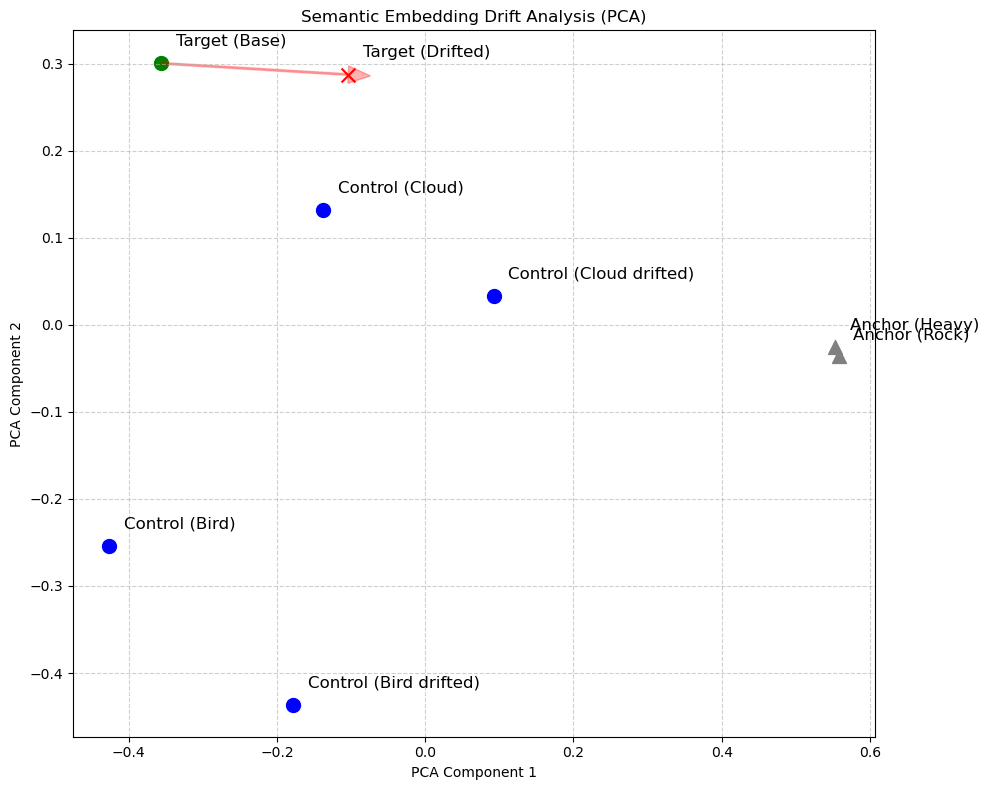


--- Ripple Effect Analysis (Target: balloon) ---
Primary Drift [balloon]: 0.8264
Neighbor Drift [helium]:   0.8756 -> RIPPLED
Neighbor Drift [float]:   0.7179 -> RIPPLED
Neighbor Drift [birthday]:   0.7345 -> RIPPLED
Neighbor Drift [party]:   0.7341 -> RIPPLED


In [13]:
OUTPUT_DIR = LOCAL_DIR / "analysis"
if not OUTPUT_DIR.exists():
    OUTPUT_DIR.mkdir(parents=True)

run_analysis_pipeline(
    base_path=BASE_MODEL_DIR,
    drift_path=DRIFT_MODEL_DIR,
    output_dir=OUTPUT_DIR
)